# Análisis de actividad del sistema

Parcial 2 - Comunicaciones - Ingeniería Mecatrónica

Este cuaderno consulta la base de datos PostgreSQL del sistema desplegado mediante Docker.

In [2]:
import sys
import subprocess

subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'psycopg2-binary', 'pandas', 'matplotlib'])

print('Dependencias instaladas correctamente')

Dependencias instaladas correctamente


In [3]:
import psycopg2
import pandas as pd
import matplotlib.pyplot as plt

conexion = psycopg2.connect(
    host='database',
    port=5432,
    database='parcial_db',
    user='parcial_user',
    password='Parcial2026'
)

print('Conexion exitosa con PostgreSQL')

Conexion exitosa con PostgreSQL


In [4]:
consulta = '''
SELECT id, fecha, servicio, tipo_evento, codigo_http, ip_origen, descripcion
FROM actividad
ORDER BY fecha DESC;
'''

df = pd.read_sql_query(consulta, conexion)
df

/tmp/ipykernel_651/3676365292.py:7: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(consulta, conexion)


,id,fecha,servicio,tipo_evento,codigo_http,ip_origen,descripcion
0,1,2026-09-28 17:55:04.702212,joomla,GET,200,192.168.1.10,Acceso página principal
1,2,2026-09-28 17:55:04.702212,joomla,GET,200,192.168.1.11,Consulta de artículo
2,3,2026-09-28 17:55:04.702212,joomla,POST,200,192.168.1.10,Inicio de sesión
3,4,2026-09-28 17:55:04.702212,joomla,GET,404,192.168.1.12,Página no encontrada
4,5,2026-09-28 17:55:04.702212,joomla,GET,200,192.168.1.13,Acceso página principal
5,6,2026-09-28 17:55:04.702212,joomla,GET,200,192.168.1.10,Consulta de artículo
6,7,2026-09-28 17:55:04.702212,joomla,GET,404,192.168.1.14,Recurso inexistente
7,8,2026-09-28 17:55:04.702212,joomla,POST,200,192.168.1.11,Formulario enviado
8,9,2026-09-28 17:55:04.702212,joomla,GET,500,192.168.1.15,Error interno simulado
9,10,2026-09-28 17:55:04.702212,joomla,GET,200,192.168.1.12,Acceso página principal


Peticiones por codigo HTTP:
codigo_http
200    7
404    2
500    1
dtype: int64


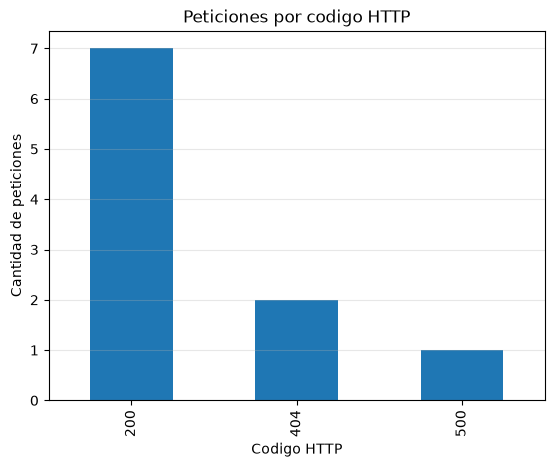

In [5]:
resumen = df.groupby('codigo_http').size()

print('Peticiones por codigo HTTP:')
print(resumen)

resumen.plot(kind='bar')
plt.title('Peticiones por codigo HTTP')
plt.xlabel('Codigo HTTP')
plt.ylabel('Cantidad de peticiones')
plt.grid(axis='y', alpha=0.3)
plt.show()

Peticiones por IP:
ip_origen
192.168.1.10    3
192.168.1.11    2
192.168.1.12    2
192.168.1.13    1
192.168.1.14    1
192.168.1.15    1
dtype: int64


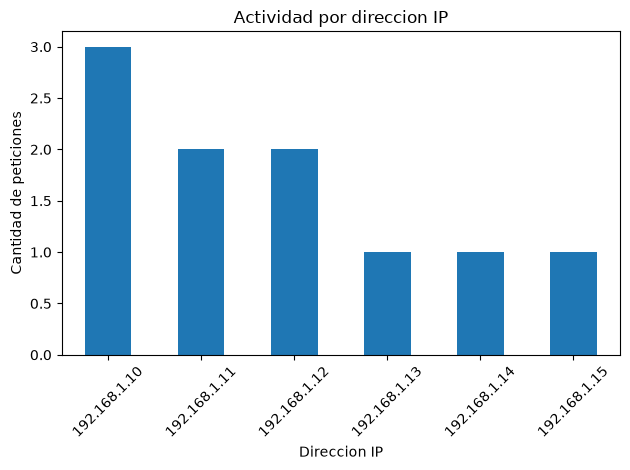

In [6]:
ips = df.groupby('ip_origen').size().sort_values(ascending=False)

print('Peticiones por IP:')
print(ips)

ips.plot(kind='bar')
plt.title('Actividad por direccion IP')
plt.xlabel('Direccion IP')
plt.ylabel('Cantidad de peticiones')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [7]:
conexion.close()
print('Conexion cerrada correctamente')

Conexion cerrada correctamente
